# Adult Income

## Problem Understanding

The goal of this project is to predict whether an individual's annual income is greater than $50K based on  employment information.

The Adult Income Dataset is a Supervised Learning problem.
- Input Features (X)
- Known Target (Y)

Target Variable:
- Income (>$50K)

Numerical Features:
- age
- fnlwgt
- education-num etc..

Objective: The objective of this project is to build a machine learning model that predicts whether a person’s annual income is greater than $50K.

## Import Libraries

Import the necessary libraries for data manipulation, visualization, and machine learning.

In [47]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


## Data Loading & Overview


In [2]:
from sklearn.datasets import fetch_openml

# Load the dataset
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
print("shape")
print(df.shape)

print("Data info:")
df.info()

print("\nBasic Statistics:")
print(df.describe())

shape
(48842, 15)
Data info:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB

Basic Statistics:
                age  

## Data Cleaning

In [12]:
# Check missing values
print("Does this Dataset contain any null values")
print(df.isnull().sum())

# Check duplicates
print("Duplicate check if any")
print(df.duplicated().sum())

Does this Dataset contain any null values
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Duplicate check if any
53


In [17]:
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])
df = df.drop_duplicates()

In [19]:
print(df.isnull().sum())
print(f"check duplicates {df.duplicated().sum()}")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
check duplicates 0


## EDA & Visualisation

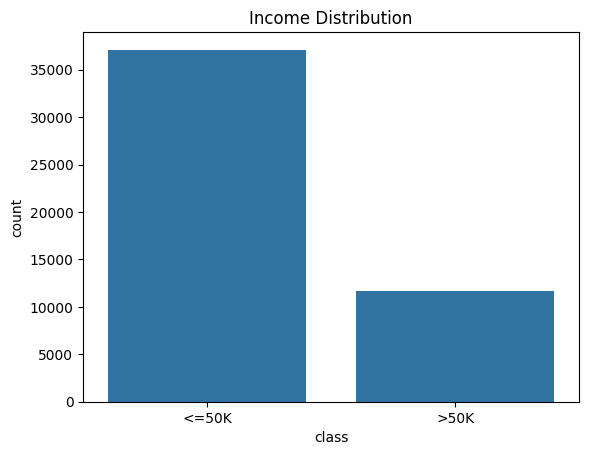

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df)
plt.title("Income Distribution")
plt.show()

## Data Preprocesssing

In [46]:
lab_enc = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = lab_enc.fit_transform(df[col])

In [35]:
X = df.drop("class", axis=1)
y = df["class"]

# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (39031, 6)
X_test shape: (9758, 6)
y_train shape: (39031,)
y_test shape: (9758,)


## Scaling

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [48]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Descision Tree
dec_tr = DecisionTreeClassifier(random_state=40, max_depth=10)
dec_tr.fit(X_train, y_train)
y_pred_dec_tr = dec_tr.predict(X_test)

# Random Forest
rn_frst = RandomForestClassifier(n_estimators=100, random_state=42)
rn_frst.fit(X_train_scaled, y_train)
y_pred_rf = rn_frst.predict(X_test_scaled)

## Model Evaluation

In [49]:
from sklearn.metrics import accuracy_score

def model_eval(y_true, y_pred, name="Model"):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"{name} -> Accuracy: {accuracy:.2f}")

model_eval(y_test, y_pred_lr, "Logistic Regression")
model_eval(y_test, y_pred_dec_tr, "Decision Tree")
model_eval(y_test, y_pred_rf, "Random Forest")

Logistic Regression -> Accuracy: 0.81
Decision Tree -> Accuracy: 0.83
Random Forest -> Accuracy: 0.81


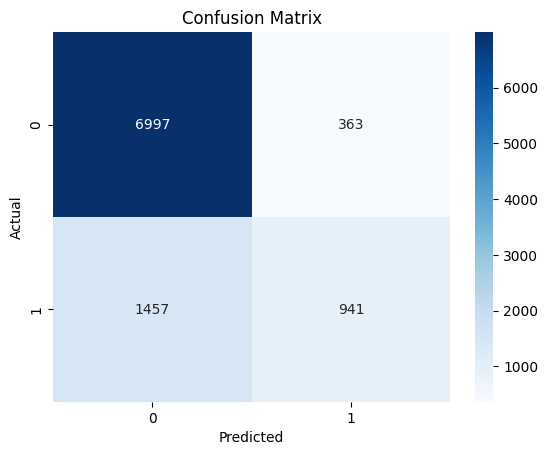

In [43]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

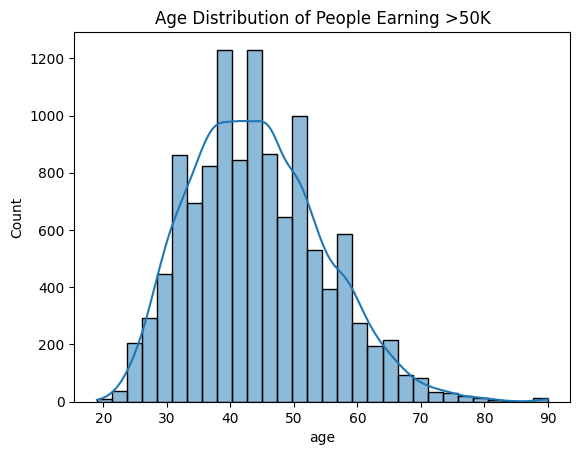

In [42]:
df_high_income = df[df['class'] == '>50K']

sns.histplot(df_high_income['age'], bins=30, kde=True)
plt.title("Age Distribution of People Earning >50K")
plt.show()

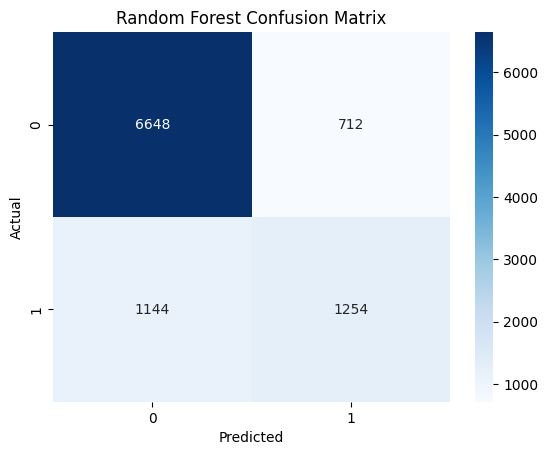

In [50]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

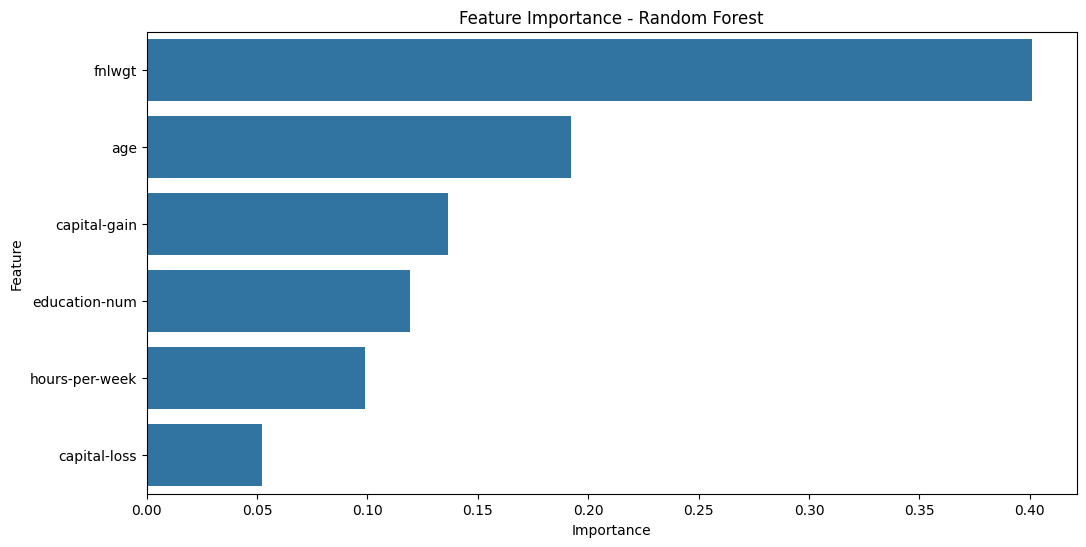

In [53]:
imp_ft = rn_frst.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": imp_ft
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()